---
title: "GSB 545 Midterm - Take Home Portion"
author: "Tyler Allen"
date: "2025-04-29"
format:
  html:
    cold-fold: true
    embed-resources: true
theme: "lux"
---

In [2]:
import pandas as pd

df1 = pd.read_csv("data1.csv")
df2 = pd.read_csv("data2.csv")

In [4]:
df1.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


In [5]:
df2.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [6]:
#combining and cleaning
combined_df = pd.concat([df1, df2], ignore_index=True)
combined_df.drop(columns=['Unnamed: 0'], inplace=True) #dop Unnamed:0
cleaned_df = combined_df.dropna() #drop rows with missing values
cleaned_df = cleaned_df.drop_duplicates() #drop duplicates
combined_df.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,3,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,3,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,2,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,4,...,2,2,2,2,4,2,4,0,20.0,satisfied


In [8]:
for col in cleaned_df.columns:
    print(f"{col}: {cleaned_df[col].dtype}")

id: int64
Gender: object
Customer Type: object
Age: int64
Type of Travel: object
Class: object
Flight Distance: int64
Inflight wifi service: int64
Departure/Arrival time convenient: int64
Ease of Online booking: int64
Gate location: int64
Food and drink: int64
Online boarding: int64
Seat comfort: int64
Inflight entertainment: int64
On-board service: int64
Leg room service: int64
Baggage handling: int64
Checkin service: int64
Inflight service: int64
Cleanliness: int64
Departure Delay in Minutes: int64
Arrival Delay in Minutes: float64
satisfaction: object


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb


Satisfaction Distribution:
satisfaction
neutral or dissatisfied    73452
satisfied                  56428
Name: count, dtype: int64


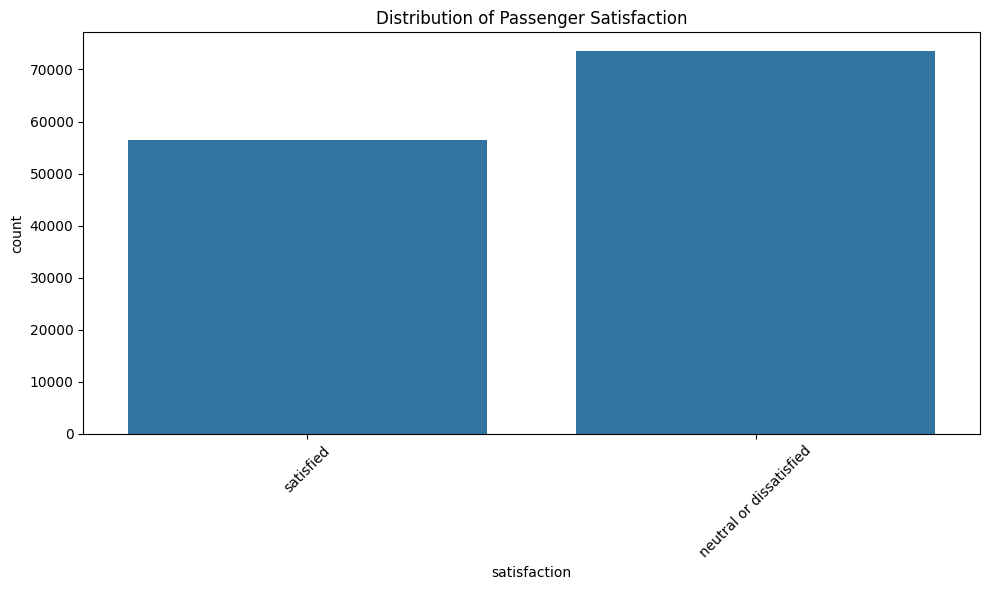

In [16]:
#Exploratory data analysis

#Satisfaction Distribution
plt.figure(figsize=(10, 6))
satisfaction_counts = combined_df['satisfaction'].value_counts()
print("\nSatisfaction Distribution:")
print(satisfaction_counts)
sns.countplot(data=combined_df, x='satisfaction')
plt.title('Distribution of Passenger Satisfaction')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

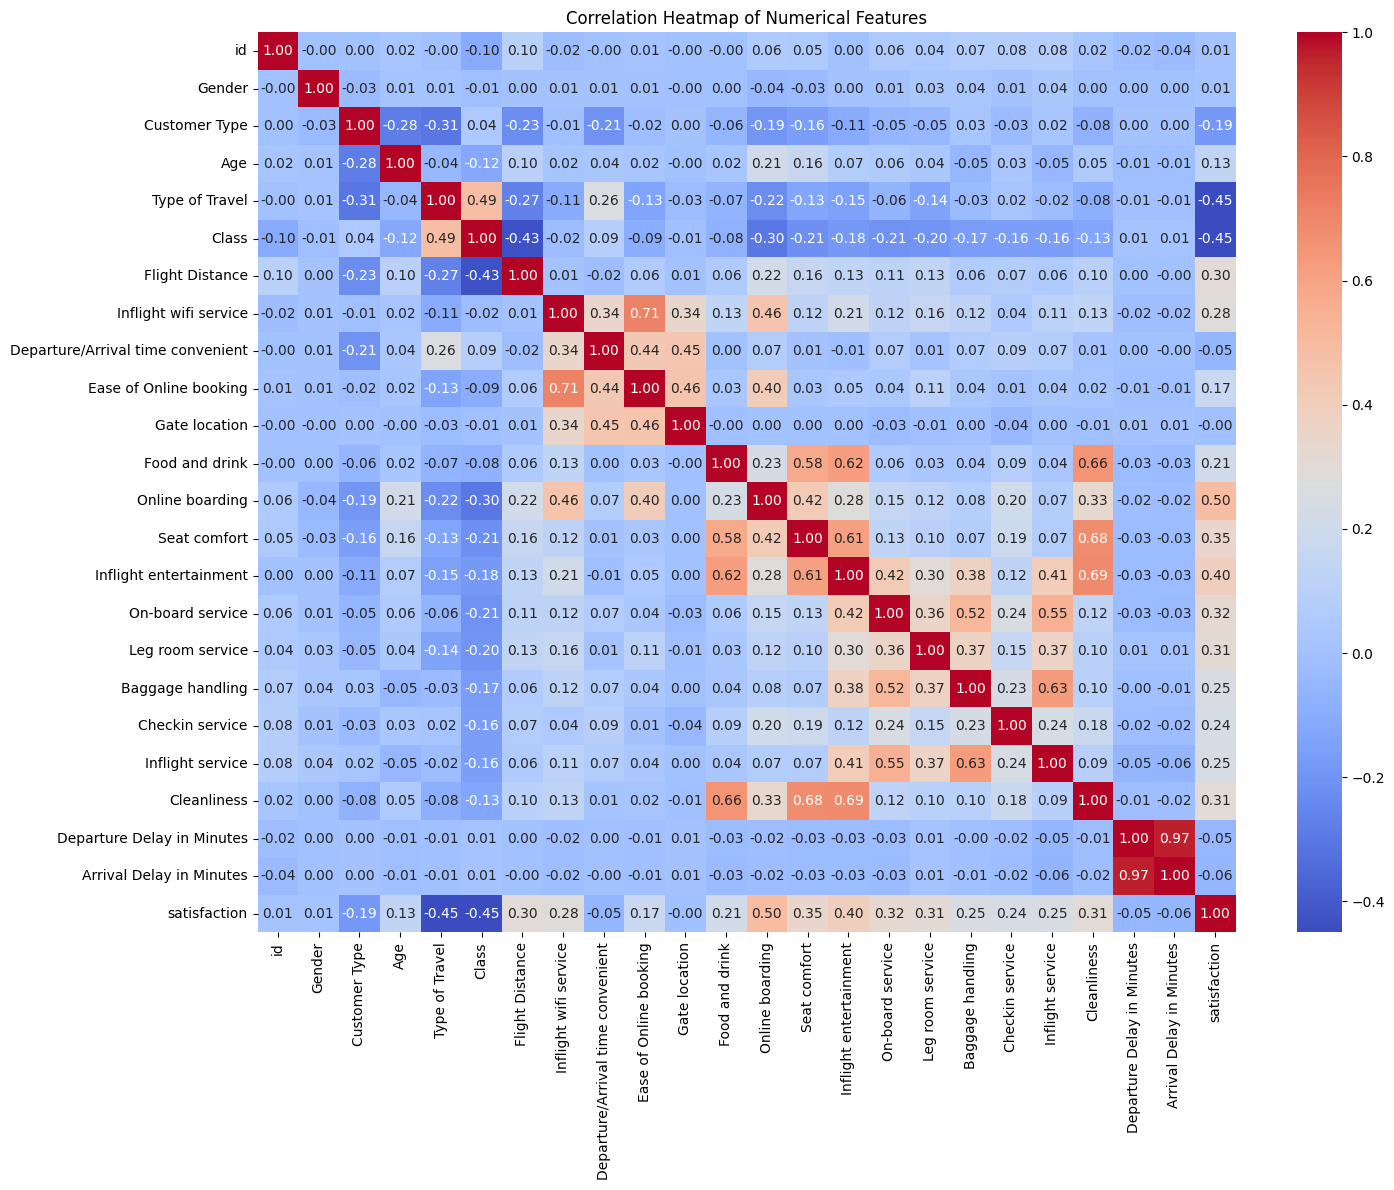


Top 5 features most correlated with satisfaction:
satisfaction              1.000000
Online boarding           0.501620
Inflight entertainment    0.398334
Seat comfort              0.348576
On-board service          0.322329
Leg room service          0.312557
Name: satisfaction, dtype: float64


In [47]:
# Correlation Analysis
plt.figure(figsize=(15, 12))
numeric_cols = cleaned_df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = cleaned_df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

#top correlations with satisfaction
satisfaction_corr = correlation_matrix['satisfaction'].sort_values(ascending=False)
print("\nTop 5 features most correlated with satisfaction:")
print(satisfaction_corr.head(6))

This answers the question "What factors are associated with passenger satisfaction?"

Remember this for later, I'll tie it back in!

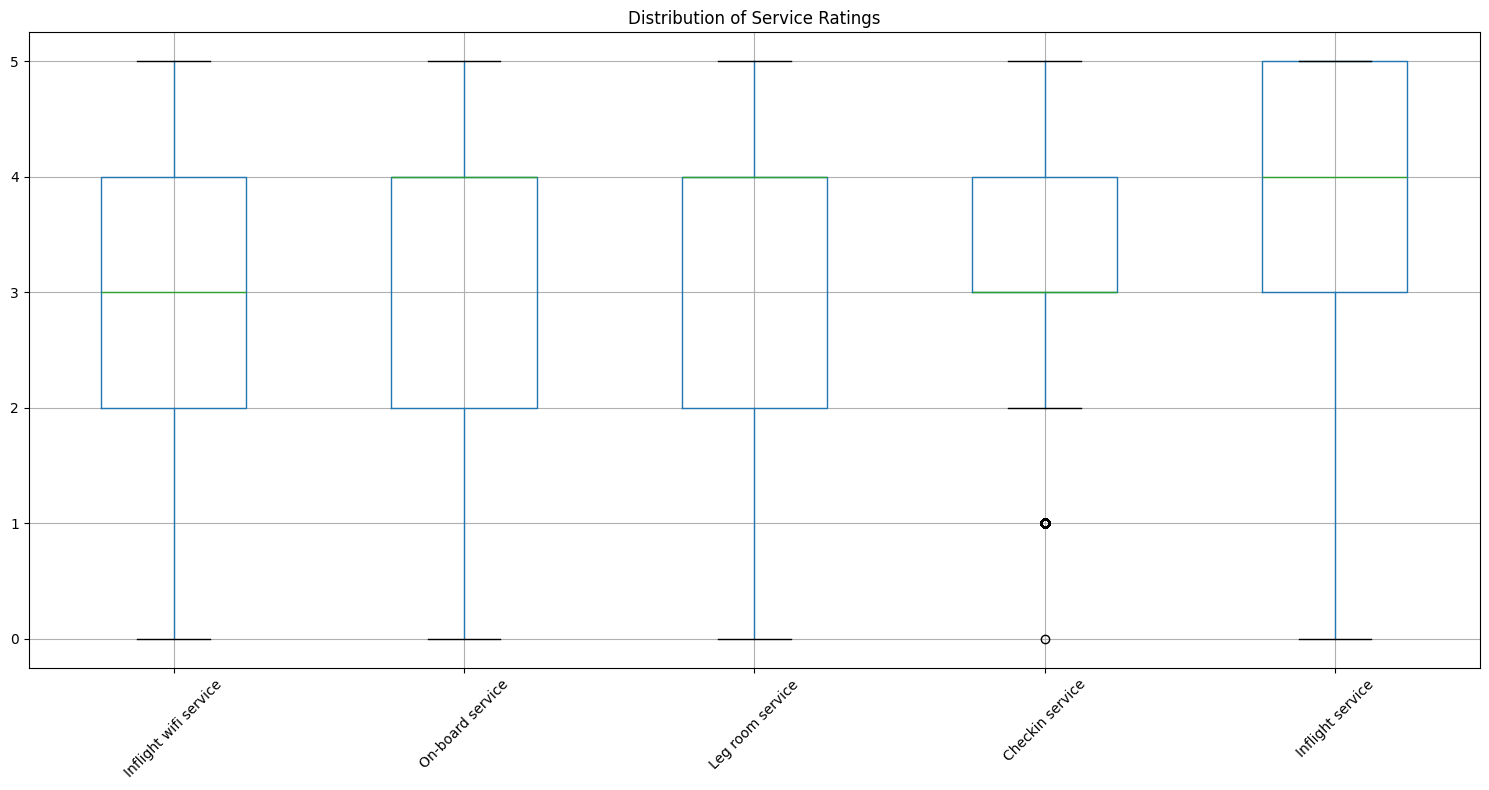


Average service ratings:
Inflight service         3.642373
On-board service         3.383204
Leg room service         3.351078
Checkin service          3.306239
Inflight wifi service    2.728544
dtype: float64


In [51]:
# Service Ratings Analysis
service_columns = [col for col in cleaned_df.columns if 'service' in col.lower()]
plt.figure(figsize=(15, 8))
cleaned_df[service_columns].boxplot()
plt.xticks(rotation=45)
plt.title('Distribution of Service Ratings')
plt.tight_layout()
plt.show()

print("\nAverage service ratings:")
print(cleaned_df[service_columns].mean().sort_values(ascending=False))

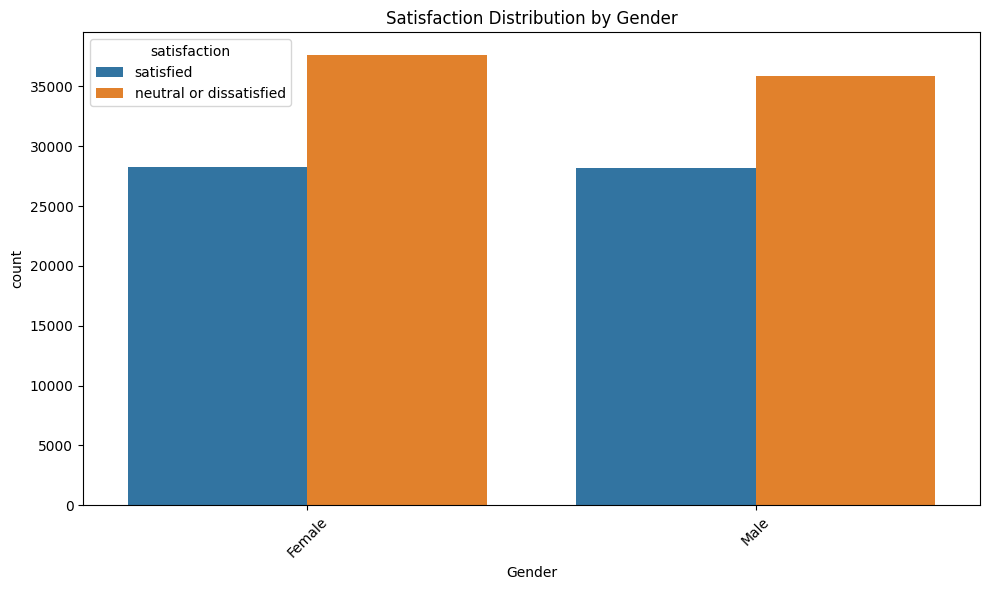


Satisfaction rates by Gender:
satisfaction  neutral or dissatisfied  satisfied
Gender                                          
Female                       0.571025   0.428975
Male                         0.559885   0.440115


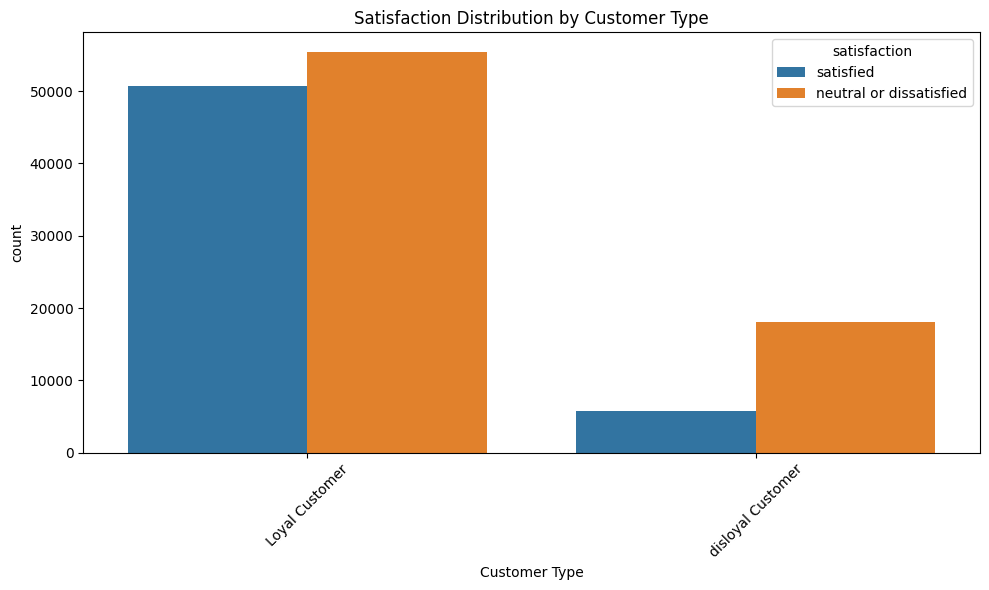


Satisfaction rates by Customer Type:
satisfaction       neutral or dissatisfied  satisfied
Customer Type                                        
Loyal Customer                    0.521885   0.478115
disloyal Customer                 0.760303   0.239697


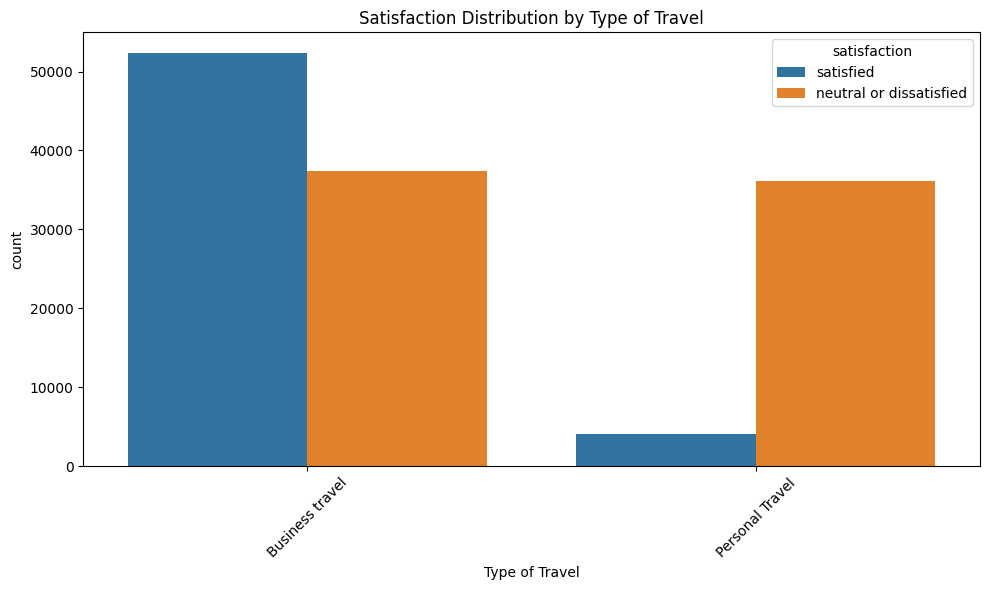


Satisfaction rates by Type of Travel:
satisfaction     neutral or dissatisfied  satisfied
Type of Travel                                     
Business travel                 0.416276   0.583724
Personal Travel                 0.898674   0.101326


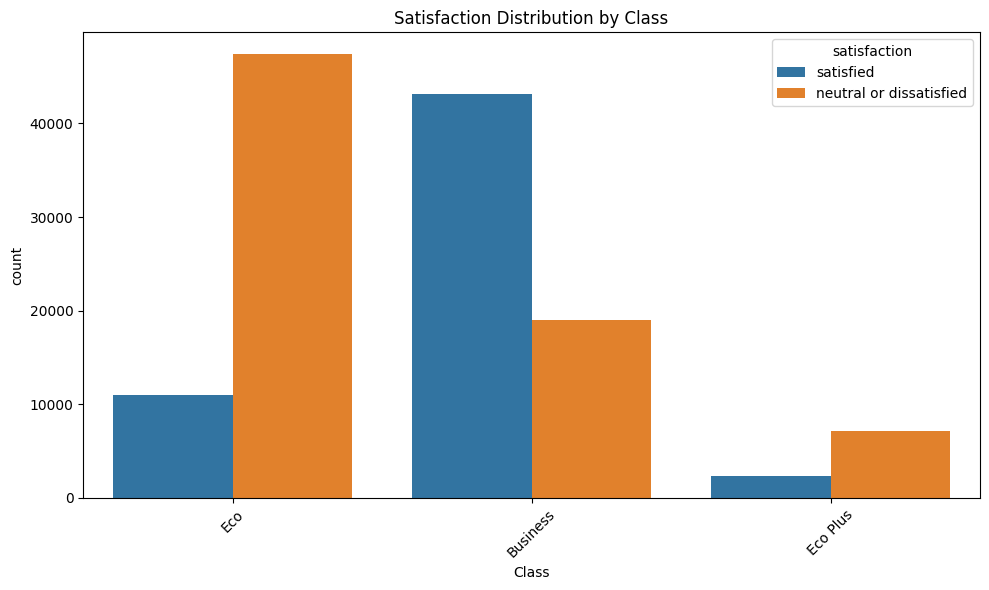


Satisfaction rates by Class:
satisfaction  neutral or dissatisfied  satisfied
Class                                           
Business                     0.305566   0.694434
Eco                          0.812327   0.187673
Eco Plus                     0.753586   0.246414


In [20]:
#categorical analysis (found a really cool function to generate these plots through AI)
categorical_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=combined_df, x=col, hue='satisfaction')
    plt.title(f'Satisfaction Distribution by {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    satisfaction_rates = combined_df.groupby(col)['satisfaction'].value_counts(normalize=True).unstack()
    print(f"\nSatisfaction rates by {col}:")
    print(satisfaction_rates)


*The alluding of predictive power in the following paragraphs was due to its use in connecting feature importances to factors associated with satisfaction later on in this file.*

**Customer Type:** Although Customer Type has lower relative importance, it still contributes to the prediction of satisfaction, likely as a proxy for past behavior or loyalty. Disloyal customers are significantly less satisfied, so this feature likely captures repeat behavior and loyalty trends.

**Type of Travel:** Business travelers likely receive better service (ie. upgrades, loyalty benefits), or have different expectations, driving the predictive power of this variable. The model picks up on this clear stratification of satisfaction.

**Class:** This is highly predictive and directly linked to the level of service received. Class influences many downstream experiences (seat comfort, amenities), so its strong importance score makes sense.

In [21]:
#Data Prep

# Encode categorical variables
categorical_columns = ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']
for column in categorical_columns:
    le = LabelEncoder()
    cleaned_df[column] = le.fit_transform(cleaned_df[column])

X = cleaned_df.drop('satisfaction', axis=1)
y = cleaned_df['satisfaction']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
#Model Evaluations

#1 Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

print("\nLogistic Regression Results:")
print(classification_report(y_test, lr_pred))


Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.87      0.91      0.89     14456
           1       0.88      0.83      0.85     11442

    accuracy                           0.87     25898
   macro avg       0.87      0.87      0.87     25898
weighted avg       0.87      0.87      0.87     25898



In [24]:
#2 Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

print("\nRandom Forest Results:")
print(classification_report(y_test, rf_pred))


Random Forest Results:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     14456
           1       0.97      0.94      0.96     11442

    accuracy                           0.96     25898
   macro avg       0.96      0.96      0.96     25898
weighted avg       0.96      0.96      0.96     25898



In [25]:
#3 XGBoost
xgb_model = xgb.XGBClassifier(random_state=42)
xgb_model.fit(X_train_scaled, y_train)
xgb_pred = xgb_model.predict(X_test_scaled)

print("\nXGBoost Results:")
print(classification_report(y_test, xgb_pred))


XGBoost Results:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     14456
           1       0.97      0.95      0.96     11442

    accuracy                           0.96     25898
   macro avg       0.97      0.96      0.96     25898
weighted avg       0.96      0.96      0.96     25898



In [30]:
#4 AdaBoost
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_train_scaled, y_train)
ada_pred = ada_model.predict(X_test_scaled)

print("\nAdaBoost Results:")
print(classification_report(y_test, ada_pred))


AdaBoost Results:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93     14456
           1       0.92      0.91      0.92     11442

    accuracy                           0.93     25898
   macro avg       0.93      0.92      0.92     25898
weighted avg       0.93      0.93      0.93     25898



In [31]:
#Comparing the models (used AI for simplicity reasons)
models = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'AdaBoost': ada_model
}

print("\nModel Accuracy Comparison:")
for name, model in models.items():
    accuracy = model.score(X_test_scaled, y_test)
    print(f"{name}: {accuracy:.4f}")


Model Accuracy Comparison:
Logistic Regression: 0.8730
Random Forest: 0.9634
XGBoost: 0.9646
AdaBoost: 0.9257


As you can see above, the XBGoost Model performed the best, barely outperforming the Random Forest model. I'm not suprised the Logistic Regression model performed the worst due to the nature of the data.

In [36]:
# Combined Feature Importance Analysis

#getting feature importances from each model
rf_importance = pd.DataFrame({
    'feature': X_train.columns,
    'RF_importance': rf_model.feature_importances_
})

ada_importance = pd.DataFrame({
    'feature': X_train.columns,
    'Ada_importance': ada_model.feature_importances_
})

xgb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'XGB_importance': xgb_model.feature_importances_
})

In [37]:
#combining all feature importances
combined_importance = rf_importance.merge(ada_importance, on='feature')
combined_importance = combined_importance.merge(xgb_importance, on='feature')

#calculating mean and standard deviation of importance scores
combined_importance['Mean_Importance'] = combined_importance[['RF_importance', 'Ada_importance', 'XGB_importance']].mean(axis=1)
combined_importance['Std_Importance'] = combined_importance[['RF_importance', 'Ada_importance', 'XGB_importance']].std(axis=1)

#sorting by mean importance
combined_importance = combined_importance.sort_values('Mean_Importance', ascending=False)

#top 10 features based on mean importance
print("\nTop 10 Features (Combined Importance):")
print(combined_importance.head(10))


Top 10 Features (Combined Importance):
                   feature  RF_importance  Ada_importance  XGB_importance  \
12         Online boarding       0.165514        0.141661        0.454726   
7    Inflight wifi service       0.134129        0.429432        0.101388   
4           Type of Travel       0.095536        0.072628        0.128035   
5                    Class       0.104956        0.065251        0.038061   
2            Customer Type       0.038302        0.055732        0.050570   
16        Leg room service       0.037896        0.043681        0.016383   
13            Seat comfort       0.053059        0.021596        0.017797   
14  Inflight entertainment       0.045222        0.008364        0.033302   
18         Checkin service       0.022654        0.027667        0.029214   
15        On-board service       0.027493        0.019641        0.019295   

    Mean_Importance  Std_Importance  
12         0.253967        0.174271  
7          0.221650        0.180688 

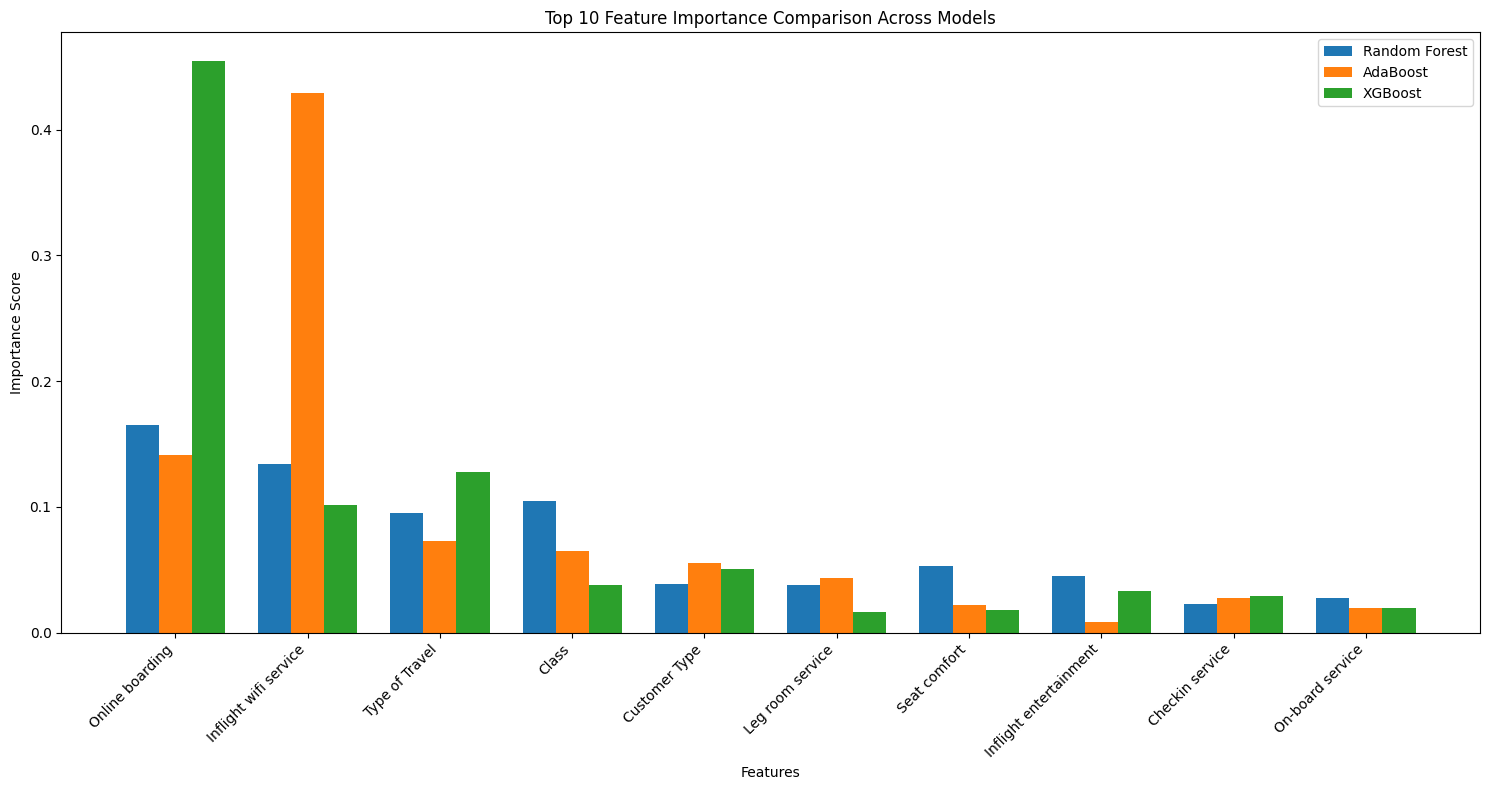

In [38]:
#visualization of combined feature importance
plt.figure(figsize=(15, 8))
top_10_features = combined_importance.head(10)

x = np.arange(len(top_10_features))
width = 0.25

plt.bar(x - width, top_10_features['RF_importance'], width, label='Random Forest')
plt.bar(x, top_10_features['Ada_importance'], width, label='AdaBoost')
plt.bar(x + width, top_10_features['XGB_importance'], width, label='XGBoost')

plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.title('Top 10 Feature Importance Comparison Across Models')
plt.xticks(x, top_10_features['feature'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

The title of the graph speaks for itself. These features are the 10 most importance features when predicting airline passenger satisfaction.

This feature importance agreement below was made by AI, and I didn't know what it was before. However, I learned that it applies to this because the data is ordinal (ratings), non-linear, and is not normally distributed. It's based on the ranks of the data, not the actual values themselves so I thought I'd test it out.

In [39]:
print("\nFeature Importance Agreement Analysis:")

# Calculate rank correlation between different models

rank_corr = pd.DataFrame(index=['RF', 'Ada', 'XGB'], columns=['RF', 'Ada', 'XGB'])
for m1 in ['RF_importance', 'Ada_importance', 'XGB_importance']:
    for m2 in ['RF_importance', 'Ada_importance', 'XGB_importance']:
        corr = combined_importance[m1].corr(combined_importance[m2], method='spearman')
        rank_corr.loc[m1.split('_')[0], m2.split('_')[0]] = corr

print("\nSpearman Rank Correlation between Model Importance Rankings:")
print(rank_corr)


Feature Importance Agreement Analysis:

Spearman Rank Correlation between Model Importance Rankings:
           RF       Ada       XGB
RF        1.0  0.669323  0.752964
Ada  0.669323       1.0  0.750754
XGB  0.752964  0.750754       1.0


In [40]:
#consistency score for top features
def get_top_n_features(importance_series, n=10):
    return set(importance_series.nlargest(n).index)

top_features = {
    'RF': get_top_n_features(combined_importance['RF_importance']),
    'Ada': get_top_n_features(combined_importance['Ada_importance']),
    'XGB': get_top_n_features(combined_importance['XGB_importance'])
}

#features that appear in all three models' top 10
common_top_features = top_features['RF'] & top_features['Ada'] & top_features['XGB']
print("\nFeatures in Top 10 for all three models:")
print(list(common_top_features))

#consistency score (percentage of features that appear in all three models' top 10)
consistency_score = len(common_top_features) / 10
print(f"\nConsistency Score (proportion of features in all models' top 10): {consistency_score:.2f}")

#robust feature importance ranking (based on mean ranking across models)
print("\nRobust Feature Ranking (based on mean importance):")
robust_features = combined_importance[['feature', 'Mean_Importance', 'Std_Importance']].head(10)
print(robust_features)


Features in Top 10 for all three models:
[2, 4, 5, 7, 12]

Consistency Score (proportion of features in all models' top 10): 0.50

Robust Feature Ranking (based on mean importance):
                   feature  Mean_Importance  Std_Importance
12         Online boarding         0.253967        0.174271
7    Inflight wifi service         0.221650        0.180688
4           Type of Travel         0.098733        0.027842
5                    Class         0.069423        0.033642
2            Customer Type         0.048202        0.008953
16        Leg room service         0.032653        0.014384
13            Seat comfort         0.030817        0.019355
14  Inflight entertainment         0.028963        0.018808
18         Checkin service         0.026512        0.003429
15        On-board service         0.022143        0.004636


As you can see above, the top 5 features in the models that contributed to the model's ability to make accurate predictions are (in order): online boarding, inflight wifi service, type of travel, class, and customer type. Now this doesn't necesarily answer the question "What factors are associated with passenger satisfaction?" because feature importance is not the same as "causes satisfaction." Below is the answer to that question.

In [52]:
#Top 5 factors associated with satisfaction
print(satisfaction_corr.drop('satisfaction').head(5))

Online boarding           0.501620
Inflight entertainment    0.398334
Seat comfort              0.348576
On-board service          0.322329
Leg room service          0.312557
Name: satisfaction, dtype: float64


The variables above are the top 5 features that are associated with satisfaction. It is interesting to note that not only is online boarding the feature that is most associated with satisfaction, but it also the feature with the most predictive power.

**Possible Sources for the Data**

The dataset appears to be a synthetic or anonymized version of an airline passenger satisfaction survey, similar to those found on platforms like Kaggle or used in academic exercises. Such data are typically collected via post-flight surveys, online feedback forms, or customer experience research conducted by airlines or third-party agencies.

**Issues to Consider with Survey Data**

*Sampling Bias:* Responses may be skewed by self-selection (only those with strong opinions respond) or underrepresentation of certain groups (ie. older travelers, non-loyalty members).

*Measurement Issues:* Satisfaction metrics are subjective; rating scales can be interpreted inconsistently. “Not Applicable” responses may distort data if not handled properly.

*Data Quality:* Incomplete or duplicate responses can affect reliability. Inconsistencies in categorical values (ie. typos) require cleaning.

*Confounding Variables:* Unmeasured factors like ticket price or staff behavior may influence satisfaction. Strongly correlated variables (like Class and Type of Travel) may obscure true effects.

**Criticisms and Suggestions for Improvement**

I think changing the satisfaction level amount from 3 (dissatisfaction, nuetral, satisfaction) to 5 (highly dissatisfied, dissatisfied, neutral, satisfied, highly satisfied) would provide more insights.

Another suggestion I have is adding demographic information (age, income, travel frequency, etc.) to allow for more in-depth analysis.

Also, I'd recommend randomizing the question order to reduce any potential response bias.

**Generalizability of Results**

The results are most generalizable to passengers similar to those who responded to the survey (ie. same airline, routes, time period, and demographic mix). If the sample is not representative (due to biases above), generalizability to all airline passengers is limited. Furthermore, results can't be applied to other airlines or places without further validation.

**Value to an Airline**

Identifying key drivers of satisfaction helps airlines prioritize improvements (ie. investing in inflight wifi, improve boarding process) so they can provide maximum satisfaction for their customers and then generate more revenue. From a marketing standpoint, segmenting satisfaction by customer type, class, or travel purpose can inform targeted marketing and service enhancements. However, causal conclusions should be drawn cautiously; further experimentation (A/B testing) may be needed to confirm what changes actually improve satisfaction.